In [1]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib


In [2]:
import glob
import xarray as xr

PATH = "/Users/lb962/Documents/GitHub/ESL/data/ml_ready/*.nc"

# Get sorted list of files
files = sorted(glob.glob(PATH))

# Open each file into a list of datasets
datasets = [xr.open_dataset(f) for f in files]

# Example: inspect or process one
for i, ds in enumerate(datasets):
    print(f"File {i}: {files[i]}")
    print(ds)

# If you want them in memory:
datasets = [ds.load() for ds in datasets]


File 0: /Users/lb962/Documents/GitHub/ESL/data/ml_ready/small_ds.nc
<xarray.Dataset> Size: 438MB
Dimensions:            (station: 9, valid_time: 750192)
Coordinates:
  * station            (station) int64 72B 1 2 3 4 5 6 7 8 10
  * valid_time         (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2025-07...
    latitude           float64 8B ...
    longitude          float64 8B ...
    station_latitude   (station) float64 72B ...
    station_longitude  (station) float64 72B ...
Data variables: (12/14)
    u10                (station, valid_time) float32 27MB ...
    v10                (station, valid_time) float32 27MB ...
    d2m                (station, valid_time) float32 27MB ...
    t2m                (station, valid_time) float32 27MB ...
    msl                (station, valid_time) float32 27MB ...
    sst                (station, valid_time) float32 27MB ...
    ...                 ...
    mwd                (station, valid_time) float32 27MB ...
    mwp                (station

In [3]:
def preprocess(ds):
    return ds.sortby("station") 

datasets = [preprocess(xr.open_dataset(f)) for f in files]
ds = xr.concat(datasets, dim="station")

In [4]:
ds_recent = ds.where(ds["valid_time"].dt.year >= 2000, drop=True)

In [5]:
ds = ds_recent

In [6]:
# Ensure time is sorted (important for derivatives)
ds = ds.sortby("valid_time")

# --- Core helpers (finite differences over hours) ---
def diff_hours(da, hours: int):
    """Finite-difference derivative over 'hours' (value change per hour)."""
    return (da - da.shift(valid_time=hours)) / hours

# --- Wind features ---
u = ds["u10"]
v = ds["v10"]
wind_speed = np.hypot(u, v).rename("wind_speed")

d_wind_1h = diff_hours(wind_speed, 1).rename("d_wind_1h")   # Δwind / 1h
d_wind_6h = diff_hours(wind_speed, 6).rename("d_wind_6h")   # Δwind / 6h

# --- Pressure derivatives (dsp/dt) ---
sp = ds["sp"]
d_sp_1h = diff_hours(sp, 1).rename("d_sp_1h")
d_sp_6h = diff_hours(sp, 6).rename("d_sp_6h")

# --- Tide shifted features ---
tide_lag1h = ds["tide"].shift(valid_time=1).rename("tide_lag1h")
tide_lag6h = ds["tide"].shift(valid_time=6).rename("tide_lag6h")
tide_lag0h = ds["tide"].shift(valid_time=0).rename("tide_lag0h")

# Make sure sorted
ds = ds.sortby("valid_time")

# Pull just tide to a tidy frame
df = ds[["tide"]].to_dataframe().reset_index()
df = df.sort_values(["station", "valid_time"])

# Compute tidal range per station (across all valid_time)
tide_range = (ds["tide"].max(dim="valid_time") - ds["tide"].min(dim="valid_time"))
tide_range = tide_range.rename("tide_range")

# --- Air density (rho_air) ---
# Use sp (Pa) and t2m (K) if available; else fallback to 1.225 kg/m^3
R_d = 287.05  # J kg^-1 K^-1
if "sp" in ds and "t2m" in ds:
    rho_air = (ds["sp"] / (R_d * ds["t2m"])).astype("float32").rename("rho_air")
else:
    rho_air = xr.zeros_like(wind_speed) + 1.225
    rho_air = rho_air.astype("float32").rename("rho_air")

# --- Drag coefficient C_D (Large & Pond style) ---
U = wind_speed
Cd = xr.where(
    U < 11.0,
    1.14e-3,
    xr.where(U <= 25.0, (0.49 + 0.065 * U) * 1e-3, 2.0e-3)
).astype("float32").rename("Cd")

# --- Wind stress components (N/m^2 = Pa) ---
tau_x = (rho_air * Cd * U * u).astype("float32").rename("tau_x")
tau_y = (rho_air * Cd * U * v).astype("float32").rename("tau_y")
tau_mag = (rho_air * Cd * U**2).astype("float32").rename("tau_mag")

# Optional: tendencies (change over 1h/6h), consistent with your diff_hours helper
tau_d1h = diff_hours(tau_mag, 1).astype("float32").rename("d_tau_1h")
tau_d6h = diff_hours(tau_mag, 6).astype("float32").rename("d_tau_6h")

# --- Assemble into one dataset ---
feat_ds = xr.Dataset(
    {
        "wind_speed": wind_speed,
        "d_wind_1h": d_wind_1h,
        "d_wind_6h": d_wind_6h,
        "d_sp_1h": d_sp_1h,
        "d_sp_6h": d_sp_6h,
        "tide_range_12h": tide_range,
        "tide_lag0h": tide_lag0h,
        "tide_lag1h": tide_lag1h,
        "tide_lag6h": tide_lag6h,
        # "d_msl_1h": d_msl_1h,  # uncomment if you computed these
        # "d_msl_6h": d_msl_6h,
        "tau_x": tau_x,
        "tau_y": tau_y,
        "tau_mag": tau_mag,
        "tau_d1h": tau_d1h,
        "tau_d6h": tau_d6h,
    }
)

# Keep original coordinates/attrs
feat_ds = feat_ds.assign_coords(
    station=ds["station"],
    valid_time=ds["valid_time"]
)
for v in feat_ds.data_vars:
    feat_ds[v].attrs.update(ds[v.split("_")[0]].attrs if v.split("_")[0] in ds.data_vars else {})

# Merge features back with original dataset (optional)
ds_engineered = xr.merge([ds, feat_ds])

In [7]:
# exclude target + sea_level + tide from predictors
predictors = [v for v in ds_engineered.data_vars if v not in ["residual", "sea_level", "tide", "longitude", "latitude", "station_longitude", "station_latitude", "station", "valid_time"]]
target = "residual"
df = ds_engineered[predictors + [target]].to_dataframe().reset_index()
df = df.dropna(subset=[target])

# per station prediction

In [8]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
RANDOM_SEED=42

def stats(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2   = r2_score(y_true, y_pred)
    denom = np.where(np.abs(y_true) < 1e-8, np.nan, np.abs(y_true))
    mape = np.nanmean(np.abs((y_true - y_pred) / denom)) * 100.0
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE_%": mape}

station_scores = []
X_cols = predictors 

# loop over each station separately
for st in df["station"].unique():
    df_st = df[df["station"] == st].sort_values("valid_time")

    # simple random split: 80% train, 20% test (by time order)
    n = len(df_st)
    n_train = int(0.8 * n)
    train_df, test_df = df_st.iloc[:n_train], df_st.iloc[n_train:]

    X_train, y_train = train_df[X_cols], train_df[target]
    X_test,  y_test  = test_df[X_cols],  test_df[target]

    model = XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        tree_method="hist",
        objective="reg:squarederror",
        eval_metric="mae",
    )

    model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)

    y_pred = model.predict(X_test)
    station_scores.append({"station": st, **stats(y_test, y_pred)})

# Summarise
scores_df = pd.DataFrame(station_scores).set_index("station")
print("\n=== Per-station scores (trained & tested on same station) ===")
print(scores_df.to_string(float_format=lambda x: f"{x:.4f}"))

print("\nMean across stations:")
print(scores_df.mean().to_string(float_format=lambda x: f"{x:.4f}"))

/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is depr


=== Per-station scores (trained & tested on same station) ===
           MAE   RMSE      R2    MAPE_%
station                                
1       0.0517 0.0701  0.7601  295.6932
2       0.0579 0.0744  0.7468  393.4254
3       0.1927 0.3452  0.0155  425.4221
4       0.0551 0.0722  0.8014  248.8518
5       0.0585 0.0756  0.8385 2306.4462
6       0.1235 0.2421  0.0970  381.6263
7       0.0611 0.0791  0.7248  323.3928
8       0.0550 0.0722  0.6836  279.9881
10      0.0581 0.0741  0.8939  198.1451
226     0.1672 0.2456  0.2624 1199.6568
227     0.0877 0.2853  0.1853  306.4011
228     0.1602 0.2035  0.5191  326.6532
229     0.5286 1.4280 -0.0435  253.4250
230     0.2909 0.7179 -0.0273  316.7579
231     0.1734 0.2221  0.4568  382.6707
232     0.1038 0.1628  0.2674  526.1732
233     0.1980 0.5018  0.0058  319.6896
234     0.2402 0.3953  0.2636  361.2306
260     0.0599 0.0786  0.7390  409.5264
12      0.0604 0.0786  0.8217  277.7857
13      0.0622 0.0793  0.7336  498.5659
14      0.0571 0.

/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [9]:
scores_df = scores_df.reset_index()

In [9]:
import pandas as pd
import numpy as np

# --- Extract per-station coordinates from ds ---
station_vals = np.ravel(ds["station"].values)
lat_vals     = np.ravel(ds["station_latitude"].values)
lon_vals     = np.ravel(ds["station_longitude"].values)

coords_df = pd.DataFrame({
    "station": station_vals,
    "lat": lat_vals,
    "lon": lon_vals
}).drop_duplicates("station")

# --- Merge with your scores_df ---
scores_with_coords = (
    scores_df.reset_index()   # bring 'station' back as column
             .merge(coords_df, on="station", how="left")
             .set_index("station")
)

print(scores_with_coords.head())


              MAE      RMSE        R2       MAPE_%        lat       lon
station                                                                
1        0.051727  0.070074  0.760058   295.693151  60.155000 -1.140000
2        0.057909  0.074406  0.746775   393.425410  61.933000  5.117000
3        0.192700  0.345197  0.015547   425.422133  60.154028 -1.140306
4        0.055128  0.072158  0.801403   248.851758  60.398046  5.320487
5        0.058465  0.075645  0.838455  2306.446207  61.933776  5.113310


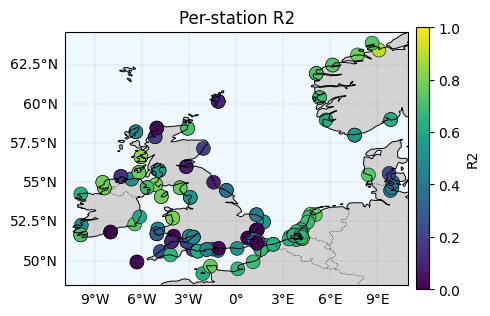

In [13]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import Normalize

# Choose metric to color by
color_metric = "R2"

# Projection
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(5, 4))
ax = plt.axes(projection=proj)

# Extent with a little padding
xmin, xmax = float(scores_with_coords["lon"].min()), float(scores_with_coords["lon"].max())
ymin, ymax = float(scores_with_coords["lat"].min()), float(scores_with_coords["lat"].max())
pad_x = max(0.5, 0.05 * (xmax - xmin))
pad_y = max(0.5, 0.05 * (ymax - ymin))
ax.set_extent([xmin - pad_x, xmax + pad_x, ymin - pad_y, ymax + pad_y], crs=proj)

# Base layers
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="aliceblue")
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":")
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5, linestyle="--")
gl.right_labels = False
gl.top_labels = False

# Scatter: color = metric, size fixed (or scale by #obs if you want)
norm = Normalize(vmin=min(0, scores_with_coords[color_metric].min()), vmax=1.0)
norm = Normalize(vmin=0, vmax=1.0)
sc = ax.scatter(
    scores_with_coords["lon"], scores_with_coords["lat"],
    c=scores_with_coords[color_metric],
    s=100, cmap="viridis", norm=norm,
    edgecolor="black", linewidth=0.4, alpha=1,
    transform=proj
)

# Colorbar
cb = plt.colorbar(sc, ax=ax, fraction=0.036, pad=0.02)
cb.set_label(color_metric)

ax.set_title(f"Per-station {color_metric}")
plt.tight_layout()
plt.show()


# Train on full

In [10]:
def stats(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2   = r2_score(y_true, y_pred)
    denom = np.where(np.abs(y_true) < 1e-8, np.nan, np.abs(y_true))
    mape = np.nanmean(np.abs((y_true - y_pred) / denom)) * 100.0
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE_%": mape}

rng = np.random.default_rng(RANDOM_SEED)
stations = np.array(sorted(df["station"].unique()))
perm = rng.permutation(stations)

n = len(perm)
n_train = int(round(0.70 * n))
n_val   = int(round(0.10 * n))
n_test  = n - n_train - n_val

train_stn = set(perm[:n_train])
val_stn   = set(perm[n_train:n_train + n_val])
test_stn  = set(perm[n_train + n_val:])

m_train = df["station"].isin(train_stn)
m_val   = df["station"].isin(val_stn)
m_test  = df["station"].isin(test_stn)

X_cols = predictors  # all other variables as predictors

X_train, y_train = df.loc[m_train, X_cols], df.loc[m_train, target]
X_val,   y_val   = df.loc[m_val,   X_cols], df.loc[m_val,   target]
X_test,  y_test  = df.loc[m_test,  X_cols], df.loc[m_test,  target]

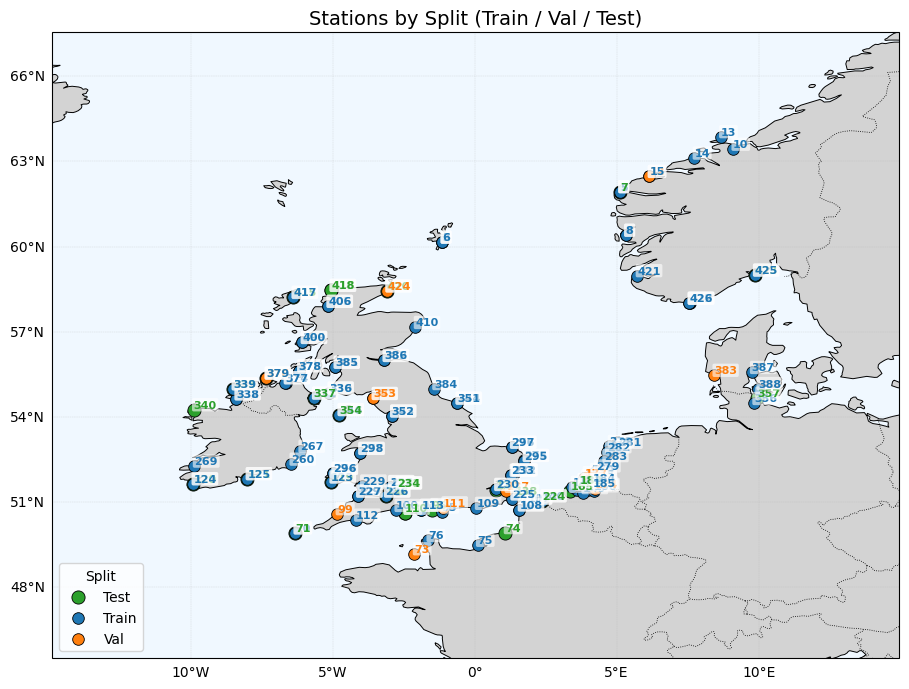

Saved: station_split_map.png


In [11]:
# pip install cartopy matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1) Unique stations with coordinates
st_meta = (
    df[["station", "station_latitude", "station_longitude"]]
    .dropna(subset=["station_latitude", "station_longitude"])
    .drop_duplicates(subset=["station"])
    .sort_values("station")
    .reset_index(drop=True)
)

# 2) Add split label
def split_label(s):
    if s in train_stn: return "train"
    if s in val_stn:   return "val"
    if s in test_stn:  return "test"
    return "unknown"

st_meta["split"] = st_meta["station"].apply(split_label)

# 3) Map setup
lon_min, lon_max = st_meta["station_longitude"].min(), st_meta["station_longitude"].max()
lat_min, lat_max = st_meta["station_latitude"].min(),  st_meta["station_latitude"].max()

# pad the extent a bit
d_lon = (lon_max - lon_min) or 1.0
d_lat = (lat_max - lat_min) or 1.0
pad = 0.25
extent = [lon_min - pad*d_lon, lon_max + pad*d_lon,
          lat_min - pad*d_lat, lat_max + pad*d_lat]

proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(10, 7))
ax = plt.axes(projection=proj)
ax.set_extent(extent, crs=proj)

# basemap features
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="aliceblue", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.6)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5, linestyle="--")
gl.right_labels = False
gl.top_labels = False

# 4) Plot by split
colors = {"train": "tab:blue", "val": "tab:orange", "test": "tab:green", "unknown": "gray"}
sizes  = {"train": 70, "val": 70, "test": 90, "unknown": 60}  # make test a bit bigger

for split, df_split in st_meta.groupby("split"):
    ax.scatter(
        df_split["station_longitude"], df_split["station_latitude"],
        s=sizes.get(split, 70),
        color=colors.get(split, "gray"),
        edgecolor="k",
        linewidth=0.6,
        transform=proj,
        zorder=5,
        label=split.capitalize()
    )

# 5) Optional: label station IDs
label_points = True
if label_points:
    for _, r in st_meta.iterrows():
        ax.text(
            r["station_longitude"], r["station_latitude"],
            f'{int(r["station"])}',
            transform=proj,
            fontsize=8, weight="bold",
            ha="left", va="bottom",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.6),
            zorder=6,
            color=colors.get(r["split"], "black")
        )

# legend & title
handles, labels = ax.get_legend_handles_labels()
# deduplicate legend entries
uniq = dict(zip(labels, handles))
ax.legend(uniq.values(), uniq.keys(), loc="lower left", title="Split")
plt.title("Stations by Split (Train / Val / Test)", fontsize=14)
plt.tight_layout()
plt.savefig("station_split_map.png", dpi=150)
plt.show()

print("Saved: station_split_map.png")


In [12]:
# ---------------------------
# 4) XGBoost model
# ---------------------------
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# ---------------------------
# 4) XGBoost model (emphasize extremes via sample_weight)
# ---------------------------
thr = np.quantile(y_train, 0.95)
w = np.ones_like(y_train, float)
w[y_train >= thr] = 3.0  # try 2–5 first, not 10–50

model = XGBRegressor(
    n_estimators=800,           # a bit more estimators with low LR
    learning_rate=0.015,
    max_depth=6,               # shallower to reduce overfit in tail
    min_child_weight=10,       # stronger regularization
    subsample=0.8,
    colsample_bytree=0.6,
    reg_lambda=10.0,
    gamma=1.0,                 # discourage tiny splits
    tree_method="hist",
    objective="reg:squarederror",
    eval_metric="mae",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

model.fit(X_train, y_train, sample_weight=w, eval_set=[(X_val, y_val)], verbose=False)

# ---------------------------
# 5) Evaluate
# ---------------------------
def evaluate(name, X, y, m):
    pred = m.predict(X)
    r2 = r2_score(y, pred)
    mae = mean_absolute_error(y, pred)
    print(f"{name:>5} | R2: {r2:.4f} | MAE: {mae:.4f}")
    return pred

print("Performance:")
_ = evaluate("Train", X_train, y_train, model)
_ = evaluate(" Val ", X_val,   y_val,   model)
test_pred = evaluate("Test ", X_test,  y_test,  model)

# ---------------------------
# 6) Save model + test predictions
# ---------------------------
#joblib.dump({"model": model, "features": X_cols}, "xgb_residual_model.joblib")
out = df.loc[m_test, ["station", "valid_time", target]].copy()
out["residual_pred"] = test_pred
out.sort_values(["station", "valid_time"]).to_parquet("test_predictions.parquet", index=False)

print("Saved: xgb_residual_model.joblib")
print("Saved: test_predictions.parquet")

Performance:
Train | R2: 0.1816 | MAE: 0.1273
 Val  | R2: 0.2627 | MAE: 0.1376
Test  | R2: 0.0481 | MAE: 0.1631
Saved: xgb_residual_model.joblib
Saved: test_predictions.parquet


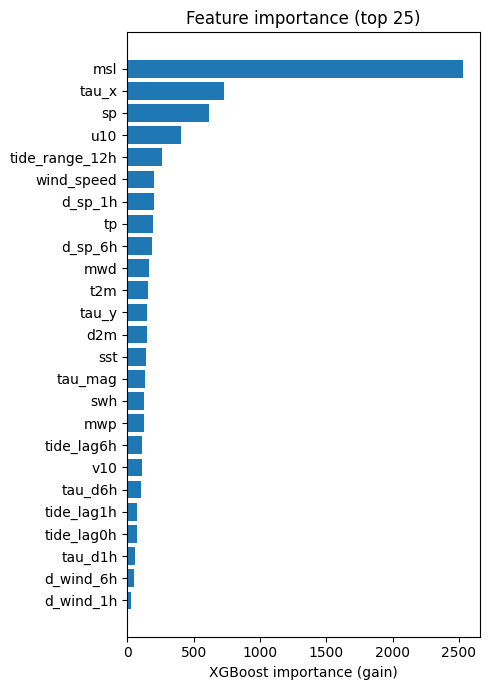

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Choose which importance definition you want: 'gain', 'weight', 'cover', 'total_gain', 'total_cover'
importance_type = 'gain'

# Grab importance from booster with your feature names
booster = model.get_booster()
# X_cols should be a list-like of your training column names (order must match X_train)
booster.feature_names = list(map(str, X_cols))

score_dict = booster.get_score(importance_type=importance_type)
# Ensure all features appear (fill missing with 0)
imp = np.array([score_dict.get(str(f), 0.0) for f in X_cols], dtype=float)

order = np.argsort(imp)[::-1]
top_k = 30  # show top-N
order = order[:top_k]

plt.figure(figsize=(5, max(2, 0.28*len(order))))
plt.barh(np.array(X_cols)[order][::-1], imp[order][::-1])
plt.xlabel(f"XGBoost importance ({importance_type})")
plt.title("Feature importance (top {})".format(len(order)))
plt.tight_layout()
plt.show()


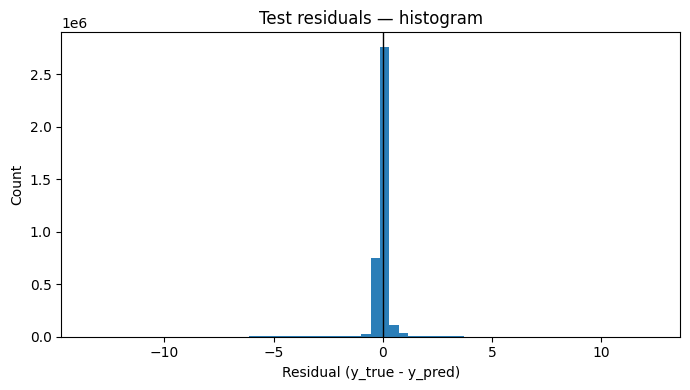

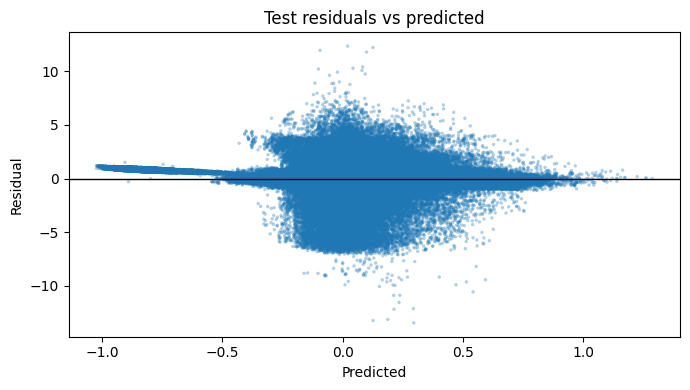

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# If starting fresh, load what you saved:
# out = pd.read_parquet("test_predictions.parquet")

# Make sure the columns are named consistently
preds = out.rename(columns={"residual_pred": "y_pred", target: "y_true"}).copy()
preds["valid_time"] = pd.to_datetime(preds["valid_time"])
preds["residual"] = preds["y_true"] - preds["y_pred"]

# --- A) Residual histogram ---
plt.figure(figsize=(7,4))
plt.hist(preds["residual"].dropna(), bins=60, alpha=0.95)
plt.axvline(0, color="k", lw=1)
plt.xlabel("Residual (y_true - y_pred)")
plt.ylabel("Count")
plt.title("Test residuals — histogram")
plt.tight_layout()
plt.show()

# --- B) Residuals vs Predicted (heteroscedasticity check) ---
plt.figure(figsize=(7,4))
plt.scatter(preds["y_pred"], preds["residual"], s=6, alpha=0.35, edgecolors="none")
plt.axhline(0, color="k", lw=1)
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Test residuals vs predicted")
plt.tight_layout()
plt.show()


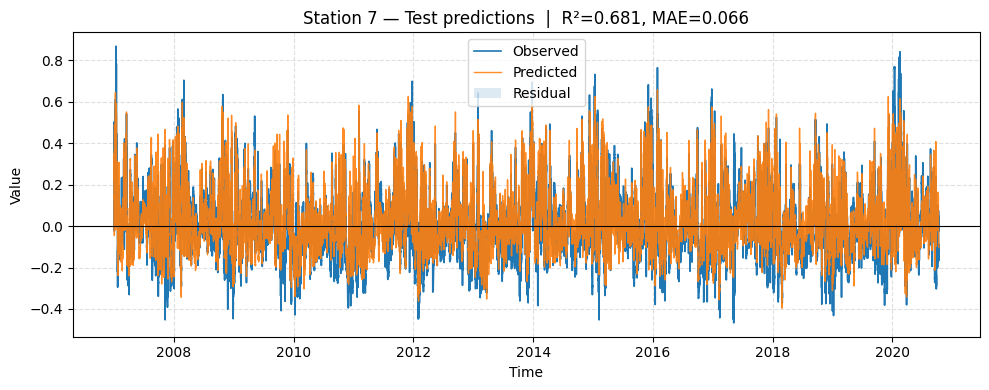

In [15]:
from sklearn.metrics import r2_score, mean_absolute_error

def plot_station_residuals(station_id):
    g = preds[preds["station"] == station_id].sort_values("valid_time")
    if g.empty:
        print(f"No test rows for station {station_id}")
        return
    r2  = r2_score(g["y_true"], g["y_pred"])
    mae = mean_absolute_error(g["y_true"], g["y_pred"])

    plt.figure(figsize=(10,4))
    plt.plot(g["valid_time"], g["y_true"], label="Observed", lw=1.2)
    plt.plot(g["valid_time"], g["y_pred"], label="Predicted", lw=1.0, alpha=0.9)
    plt.fill_between(g["valid_time"], g["y_pred"], g["y_true"], alpha=0.15, label="Residual")
    plt.axhline(0, color="k", lw=0.8)
    plt.title(f"Station {station_id} — Test predictions  |  R²={r2:.3f}, MAE={mae:.3f}")
    plt.xlabel("Time"); plt.ylabel("Value"); plt.grid(True, ls="--", alpha=0.4)
    plt.legend(); plt.tight_layout(); plt.show()

# Example:
plot_station_residuals(preds['station'].iloc[0])


In [18]:
preds

,station,valid_time,y_true,y_pred,residual
1406760,7,2007-01-01 00:00:00,0.455451,0.323039,0.132412
1406761,7,2007-01-01 01:00:00,0.459005,0.349475,0.109530
1406762,7,2007-01-01 02:00:00,0.456246,0.303043,0.153204
1406763,7,2007-01-01 03:00:00,0.384327,0.312779,0.071547
1406764,7,2007-01-01 04:00:00,0.315033,0.306583,0.008450
...,...,...,...,...,...
40095188,224,2020-09-30 20:00:00,-0.067181,0.056578,-0.123759
40095189,224,2020-09-30 21:00:00,0.020431,0.082280,-0.061849
40095190,224,2020-09-30 22:00:00,0.201872,0.160117,0.041755
40095191,224,2020-09-30 23:00:00,-0.046113,0.028163,-0.074276


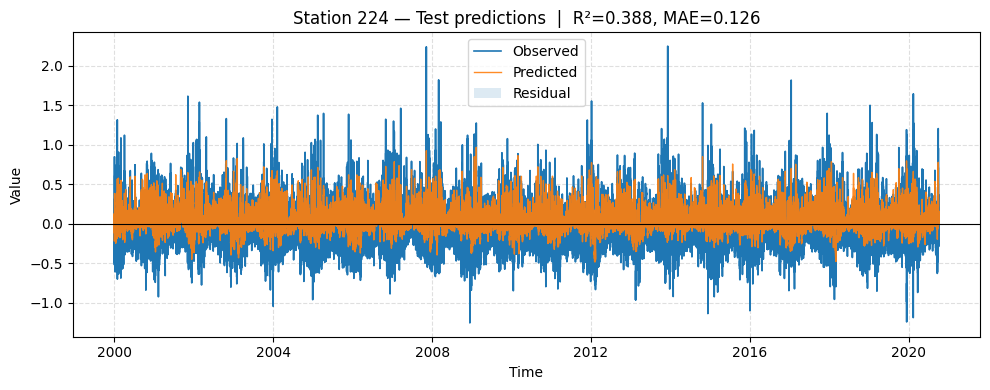

In [22]:
from sklearn.metrics import r2_score, mean_absolute_error

def plot_station_residuals(station_id):
    g = preds[preds["station"] == station_id].sort_values("valid_time")
    if g.empty:
        print(f"No test rows for station {station_id}")
        return
    r2  = r2_score(g["y_true"], g["y_pred"])
    mae = mean_absolute_error(g["y_true"], g["y_pred"])

    plt.figure(figsize=(10,4))
    plt.plot(g["valid_time"], g["y_true"], label="Observed", lw=1.2)
    plt.plot(g["valid_time"], g["y_pred"], label="Predicted", lw=1.0, alpha=0.9)
    plt.fill_between(g["valid_time"], g["y_pred"], g["y_true"], alpha=0.15, label="Residual")
    plt.axhline(0, color="k", lw=0.8)
    plt.title(f"Station {station_id} — Test predictions  |  R²={r2:.3f}, MAE={mae:.3f}")
    plt.xlabel("Time"); plt.ylabel("Value"); plt.grid(True, ls="--", alpha=0.4)
    plt.legend(); plt.tight_layout(); plt.show()

# Example:
plot_station_residuals(preds['station'].iloc[3736151])

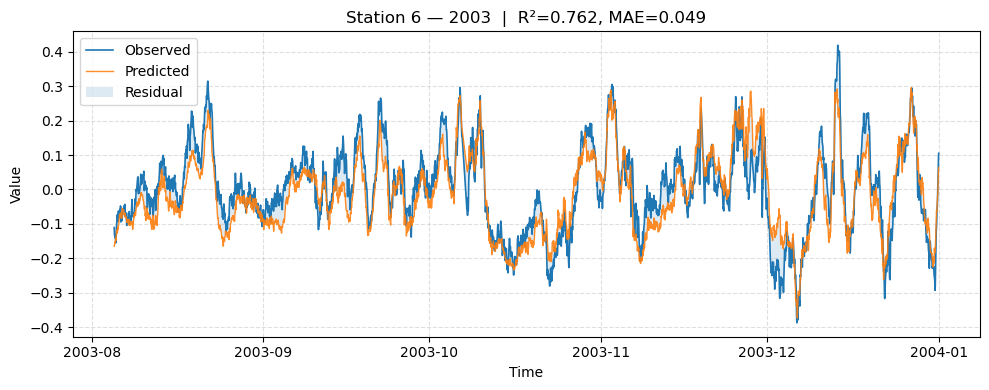

In [51]:
from sklearn.metrics import r2_score, mean_absolute_error

def plot_station_residuals(station_id, year=None):
    g = preds[preds["station"] == station_id].sort_values("valid_time").copy()
    if g.empty:
        print(f"No test rows for station {station_id}")
        return
    
    if year is not None:
        g = g[g["valid_time"].dt.year == year]
        if g.empty:
            print(f"No test rows for station {station_id} in year {year}")
            return
    
    r2  = r2_score(g["y_true"], g["y_pred"])
    mae = mean_absolute_error(g["y_true"], g["y_pred"])

    plt.figure(figsize=(10,4))
    plt.plot(g["valid_time"], g["y_true"], label="Observed", lw=1.2)
    plt.plot(g["valid_time"], g["y_pred"], label="Predicted", lw=1.0, alpha=0.9)
    plt.fill_between(g["valid_time"], g["y_pred"], g["y_true"], alpha=0.15, label="Residual")
    plt.title(f"Station {station_id} — {year if year else 'Full period'}  |  R²={r2:.3f}, MAE={mae:.3f}")
    plt.xlabel("Time"); plt.ylabel("Value")
    plt.grid(True, ls="--", alpha=0.4)
    plt.legend(); plt.tight_layout(); plt.show()

# Example: first station in 2017
plot_station_residuals(preds['station'].iloc[0], year=2003)


In [ ]:
# --- replace your Section 4–6 with this MLP version ---

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
import pandas as pd

# 4) MLP model (with impute+scale)
mlp_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler(with_mean=True, with_std=True)),
    ("mlp",     MLPRegressor(
        hidden_layer_sizes=(256, 128, 64),  # try (256,128) or (512,256,128) if you want more capacity
        activation="relu",
        solver="adam",
        alpha=1e-4,              # L2 weight decay
        learning_rate_init=1e-3,
        batch_size=2048,         # tune depending on RAM
        max_iter=200,            # optimizer steps (epochs)
        early_stopping=True,     # uses 10% of TRAIN as internal validation
        n_iter_no_change=15,
        validation_fraction=0.1,
        shuffle=True,
        random_state=RANDOM_SEED,
        verbose=False,
    ))
])

mlp_pipe.fit(X_train, y_train)

# 5) Evaluate
def evaluate(name, X, y, m):
    pred = m.predict(X)
    r2 = r2_score(y, pred)
    mae = mean_absolute_error(y, pred)
    print(f"{name:>5} | R2: {r2:.4f} | MAE: {mae:.4f}")
    return pred

print("Performance (MLP):")
_ = evaluate("Train", X_train, y_train, mlp_pipe)
_ = evaluate(" Val ", X_val,   y_val,   mlp_pipe)
test_pred = evaluate("Test ", X_test,  y_test,  mlp_pipe)

# 6) Save test predictions (same as before)
out = df.loc[m_test, ["station", "valid_time", target]].copy()
out["residual_pred"] = test_pred
out.sort_values(["station", "valid_time"]).to_parquet("test_predictions.parquet", index=False)

print("Saved: test_predictions.parquet")

/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


Performance (MLP):


In [ ]:
# pip install tensorflow scikit-learn numpy pandas

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras

# ---------------------------
# 0) Config
# ---------------------------
LOOKBACK = 72          # timesteps per sample (e.g., 72 hours)
BATCH_SIZE = 256
EPOCHS = 40
RANDOM_SEED = 1        # you already set this above
TARGET = target        # "residual"
FEATURES = X_cols      # your predictors (exclude residual/sea_level/tide)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# ---------------------------
# 1) Prepare tidy frames (same split you already created)
# ---------------------------
def tidy(df_part):
    # ensure sorted by (station, time)
    return (df_part[["station","valid_time"] + FEATURES + [TARGET]]
            .sort_values(["station","valid_time"])
            .reset_index(drop=True))

train_df = tidy(df.loc[m_train])
val_df   = tidy(df.loc[m_val])
test_df  = tidy(df.loc[m_test])

# ---------------------------
# 2) Impute & scale features (fit on TRAIN stations only)
# ---------------------------
imp = SimpleImputer(strategy="median")
sc  = StandardScaler()

Xtr = imp.fit_transform(train_df[FEATURES])
Xtr = sc.fit_transform(Xtr)

Xva = sc.transform(imp.transform(val_df[FEATURES]))
Xte = sc.transform(imp.transform(test_df[FEATURES]))

ytr = train_df[TARGET].values
yva = val_df[TARGET].values
yte = test_df[TARGET].values

# Keep ids to map predictions back
id_tr = train_df[["station","valid_time"]].values
id_va = val_df[["station","valid_time"]].values
id_te = test_df[["station","valid_time"]].values

# ---------------------------
# 3) Build sequences per station (no cross-station mixing)
# ---------------------------
def make_sequences(X, y, ids, stations, lookback=72):
    """
    X: np.array [n, p]
    y: np.array [n]
    ids: array of [station, timestamp]
    stations: array same length as X of station ids
    returns: X_seq [m, lookback, p], y_seq [m], ids_seq [m, 2]
    """
    X_list, y_list, id_list = [], [], []
    # indices per station in contiguous blocks (data are sorted)
    stn = stations.reshape(-1)
    _, start_idx, counts = np.unique(stn, return_counts=True, return_index=True)
    for s_idx, cnt in zip(start_idx, counts):
        lo, hi = s_idx, s_idx + cnt
        Xi, yi, idi = X[lo:hi], y[lo:hi], ids[lo:hi]
        if len(Xi) < lookback: 
            continue
        # sliding window within this station only
        for t in range(lookback-1, len(Xi)):
            X_list.append(Xi[t-lookback+1:t+1, :])
            y_list.append(yi[t])                 # predict residual at time t
            id_list.append(idi[t])               # (station, valid_time at t)
    if not X_list:
        return (np.empty((0, lookback, X.shape[1]), dtype=np.float32),
                np.empty((0,), dtype=np.float32),
                np.empty((0, 2), dtype=object))
    return (np.asarray(X_list, dtype=np.float32),
            np.asarray(y_list, dtype=np.float32),
            np.asarray(id_list, dtype=object))

# station arrays (sorted already)
st_tr = train_df["station"].values
st_va = val_df["station"].values
st_te = test_df["station"].values

Xtr_seq, ytr_seq, idtr_seq = make_sequences(Xtr, ytr, id_tr, st_tr, LOOKBACK)
Xva_seq, yva_seq, idva_seq = make_sequences(Xva, yva, id_va, st_va, LOOKBACK)
Xte_seq, yte_seq, idte_seq = make_sequences(Xte, yte, id_te, st_te, LOOKBACK)

print(f"Seq shapes -> train: {Xtr_seq.shape}, val: {Xva_seq.shape}, test: {Xte_seq.shape}")

# ---------------------------
# 4) tf.data pipelines
# ---------------------------
def ds_from_arrays(X, y, batch):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    return ds.shuffle(len(X), seed=RANDOM_SEED).batch(batch).prefetch(tf.data.AUTOTUNE)

train_ds = ds_from_arrays(Xtr_seq, ytr_seq, BATCH_SIZE)
val_ds   = tf.data.Dataset.from_tensor_slices((Xva_seq, yva_seq)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds  = tf.data.Dataset.from_tensor_slices((Xte_seq, yte_seq)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# ---------------------------
# 5) LSTM model
# ---------------------------
n_features = Xtr_seq.shape[-1]
inp = keras.Input(shape=(LOOKBACK, n_features))
x = keras.layers.LSTM(128, return_sequences=True)(inp)
x = keras.layers.LSTM(64)(x)
x = keras.layers.Dense(64, activation="relu")(x)
out = keras.layers.Dense(1)(x)

model = keras.Model(inp, out)
model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mae")

callbacks = [
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1),
]

history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks, verbose=1)

# ---------------------------
# 6) Evaluate (MAE / RMSE / R2) and save predictions
# ---------------------------
def evaluate(name, ds, y_true, ids_arr):
    y_pred = model.predict(ds, verbose=0).ravel()
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2   = r2_score(y_true, y_pred)
    print(f"{name:>5} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")
    pred_df = pd.DataFrame(ids_arr, columns=["station","valid_time"])
    pred_df["valid_time"] = pd.to_datetime(pred_df["valid_time"])
    pred_df["residual"] = y_true
    pred_df["residual_pred"] = y_pred
    return pred_df

print("Performance (LSTM):")
train_pred_df = evaluate("Train", train_ds, ytr_seq, idtr_seq)
val_pred_df   = evaluate(" Val ", val_ds,   yva_seq, idva_seq)
test_pred_df  = evaluate("Test ", test_ds,  yte_seq, idte_seq)

# Save test predictions like before (station, valid_time, residual, residual_pred)
test_pred_df.sort_values(["station","valid_time"]).to_parquet("test_predictions_lstm.parquet", index=False)
print("Saved: test_predictions_lstm.parquet")

# Optional: plot training curves
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.plot(history.history["loss"], label="Train MAE")
plt.plot(history.history["val_loss"], label="Val MAE")
plt.xlabel("Epoch"); plt.ylabel("MAE"); plt.title("LSTM Training"); plt.legend(); plt.tight_layout()
plt.savefig("lstm_training_curve.png", dpi=150); plt.show()
print("Saved: lstm_training_curve.png")


In [ ]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib matplotlib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
import matplotlib.pyplot as plt
import joblib

PATH = "/Users/lb962/Documents/GitHub/ESL/data/ml_ready/small_ds.nc"
RANDOM_SEED = 42
target = "residual"

# ---------------------------
# 1) Load (no Dask) & prepare predictors
# ---------------------------
ds = xr.open_dataset(PATH)
ds.load()

# exclude target + sea_level + tide from predictors
predictors = [v for v in ds.data_vars if v not in ["residual", "sea_level", "tide"]]

df = ds[predictors + [target]].to_dataframe().reset_index()
df = df.dropna(subset=[target])

# ---------------------------
# 2) Station split (70/20/10)
# ---------------------------
rng = np.random.default_rng(RANDOM_SEED)
stations = np.array(sorted(df["station"].unique()))
perm = rng.permutation(stations)

n = len(perm)
n_train = int(round(0.70 * n))
n_val   = int(round(0.20 * n))
n_test  = n - n_train - n_val

train_stn = set(perm[:n_train])
val_stn   = set(perm[n_train:n_train + n_val])
test_stn  = set(perm[n_train + n_val:])

m_train = df["station"].isin(train_stn)
m_val   = df["station"].isin(val_stn)
m_test  = df["station"].isin(test_stn)

X_cols = predictors

X_train, y_train = df.loc[m_train, X_cols], df.loc[m_train, target]
X_val,   y_val   = df.loc[m_val,   X_cols], df.loc[m_val,   target]
X_test,  y_test  = df.loc[m_test,  X_cols], df.loc[m_test,  target]

# ---------------------------
# 3) Hyperparameter tuning with Grouped CV (by station)
# ---------------------------
# Ensure CV folds do not mix stations:
groups = df.loc[m_train, "station"].values
n_splits = max(2, min(3, len(train_stn)))   # at least 2 splits
cv = GroupKFold(n_splits=n_splits)

base_est = XGBRegressor(
    random_state=RANDOM_SEED,
    n_jobs=-1,
    tree_method="hist",     # fast & memory-efficient
    objective="reg:squarederror",
)

param_dist = {
    "n_estimators":       [400, 600, 800, 1000, 1400],
    "learning_rate":      [0.02, 0.05, 0.08, 0.10],
    "max_depth":          [4, 6, 8, 10],
    "min_child_weight":   [1, 3, 6, 10],
    "subsample":          [0.7, 0.85, 1.0],
    "colsample_bytree":   [0.6, 0.8, 1.0],
    "reg_lambda":         [0.1, 1.0, 5.0, 10.0],
    "gamma":              [0.0, 0.1, 0.5, 1.0],
}

search = RandomizedSearchCV(
    estimator=base_est,
    param_distributions=param_dist,
    n_iter=24,                 # increase for a deeper search
    scoring="neg_mean_absolute_error",
    cv=cv,
    refit=True,                # refits on the full training set (m_train)
    verbose=1,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

search.fit(X_train, y_train, groups=groups)
best_params = search.best_params_
print("Best params (CV by station):")
print(best_params)

# ---------------------------
# 4) Refit best model with early stopping (monitor on VAL ONLY)
# ---------------------------
best = XGBRegressor(
    **best_params,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    tree_method="hist",
    objective="reg:squarederror",
)

# Early stopping looks only at the FIRST eval_set entry -> VAL
best.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val), (X_test, y_test)],
    eval_metric="mae",
    early_stopping_rounds=50,
    verbose=False,
)

print(f"Best iteration (early-stopped on val): {best.best_iteration}")

# ---------------------------
# 5) Evaluate final model
# ---------------------------
def evaluate(name, X, y, m):
    # When early stopping is used, use predictions up to best_iteration
    if hasattr(m, "best_iteration") and m.best_iteration is not None:
        preds = m.predict(X, iteration_range=(0, m.best_iteration + 1))
    else:
        preds = m.predict(X)
    r2  = r2_score(y, preds)
    mae = mean_absolute_error(y, preds)
    print(f"{name:>5} | R2: {r2:.4f} | MAE: {mae:.4f}")
    return preds

print("Performance:")
_ = evaluate("Train", X_train, y_train, best)
val_pred  = evaluate(" Val ", X_val,   y_val,   best)
test_pred = evaluate("Test ", X_test,  y_test,  best)

# ---------------------------
# 6) Plot learning curves (MAE vs boosting rounds) for VAL & TEST
# ---------------------------
results = best.evals_result()  # dict: {'validation_0': {'mae': [...]}, 'validation_1': {'mae': [...]}}

val_mae  = results["validation_0"]["mae"]
test_mae = results["validation_1"]["mae"]
rounds = np.arange(1, len(val_mae) + 1)

plt.figure(figsize=(8, 5))
plt.plot(rounds, val_mae, label="Validation MAE")
plt.plot(rounds, test_mae, label="Test MAE")
plt.axvline(best.best_iteration + 1, linestyle="--", alpha=0.7, label="Best iteration (val)")
plt.xlabel("Boosting rounds")
plt.ylabel("MAE")
plt.title("XGBoost Learning Curves (Val & Test)")
plt.legend()
plt.tight_layout()
plt.savefig("learning_curves_val_test.png", dpi=150)
plt.show()
print("Saved: learning_curves_val_test.png")

# ---------------------------
# 7) Save predictions
# ---------------------------
out = df.loc[m_test, ["station", "valid_time", target]].copy()
out["residual_pred"] = test_pred
out.sort_values(["station", "valid_time"]).to_parquet("test_predictions.parquet", index=False)
print("Saved: test_predictions.parquet")

# (Optional) Save the trained model and its feature list
joblib.dump({"model": best, "features": X_cols, "best_params": best_params}, "xgb_residual_model.joblib")
print("Saved: xgb_residual_model.joblib")


Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best params (CV by station):
{'subsample': 1.0, 'reg_lambda': 5.0, 'n_estimators': 600, 'min_child_weight': 6, 'max_depth': 10, 'learning_rate': 0.02, 'gamma': 0.0, 'colsample_bytree': 0.6}


TypeError: XGBModel.fit() got an unexpected keyword argument 'eval_metric'

In [ ]:
# ---------------------------
# 3) Station split (70/20/10)
# ---------------------------
rng = np.random.default_rng(RANDOM_SEED)
stations = np.array(sorted(df["station"].unique()))
perm = rng.permutation(stations)

n = len(perm)
n_train = int(round(0.70 * n))
n_val   = int(round(0.20 * n))
n_test  = n - n_train - n_val

train_stn = set(perm[:n_train])
val_stn   = set(perm[n_train:n_train + n_val])
test_stn  = set(perm[n_train + n_val:])

m_train = df["station"].isin(train_stn)
m_val   = df["station"].isin(val_stn)
m_test  = df["station"].isin(test_stn)

X_cols = predictors  # all other variables as predictors

X_train, y_train = df.loc[m_train, X_cols], df.loc[m_train, target]
X_val,   y_val   = df.loc[m_val,   X_cols], df.loc[m_val,   target]
X_test,  y_test  = df.loc[m_test,  X_cols], df.loc[m_test,  target]

# ---------------------------
# 4) XGBoost model
# ---------------------------
model = XGBRegressor(
    n_estimators=600,
    learning_rate=0.02,
    max_depth=10,
    subsample=1,
    colsample_bytree=0.6,
    reg_lambda=5,
    min_child_weight= 6,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    gamma=0.0,
    tree_method="hist",   # fast and memory-efficient
)

# XGBoost natively handles NaNs in features
model.fit(X_train, y_train,
          eval_set=[(X_val, y_val)],
          verbose=False)

# ---------------------------
# 5) Evaluate
# ---------------------------
def evaluate(name, X, y, m):
    pred = m.predict(X)
    r2 = r2_score(y, pred)
    mae = mean_absolute_error(y, pred)
    print(f"{name:>5} | R2: {r2:.4f} | MAE: {mae:.4f}")
    return pred

print("Performance:")
_ = evaluate("Train", X_train, y_train, model)
_ = evaluate(" Val ", X_val,   y_val,   model)
test_pred = evaluate("Test ", X_test,  y_test,  model)

# ---------------------------
# 6) Save model + test predictions
# ---------------------------
#joblib.dump({"model": model, "features": X_cols}, "xgb_residual_model.joblib")
out = df.loc[m_test, ["station", "valid_time", target]].copy()
out["residual_pred"] = test_pred
out.sort_values(["station", "valid_time"]).to_parquet("test_predictions.parquet", index=False)

print("Saved: xgb_residual_model.joblib")
print("Saved: test_predictions.parquet")

Performance:
Train | R2: 0.5978 | MAE: 0.0758
 Val  | R2: 0.7357 | MAE: 0.0534
Test  | R2: 0.3424 | MAE: 0.1457
Saved: xgb_residual_model.joblib
Saved: test_predictions.parquet


In [ ]:
# ---------------------------
# 3) Station split (70/20/10)
# ---------------------------
rng = np.random.default_rng(RANDOM_SEED)
stations = np.array(sorted(df["station"].unique()))
perm = rng.permutation(stations)

n = len(perm)
n_train = int(round(0.70 * n))
n_val   = int(round(0.20 * n))
n_test  = n - n_train - n_val

train_stn = set(perm[:n_train])
val_stn   = set(perm[n_train:n_train + n_val])
test_stn  = set(perm[n_train + n_val:])

m_train = df["station"].isin(train_stn)
m_val   = df["station"].isin(val_stn)
m_test  = df["station"].isin(test_stn)

X_cols = predictors  # all other variables as predictors

X_train, y_train = df.loc[m_train, X_cols], df.loc[m_train, target]
X_val,   y_val   = df.loc[m_val,   X_cols], df.loc[m_val,   target]
X_test,  y_test  = df.loc[m_test,  X_cols], df.loc[m_test,  target]

# ---------------------------
# 4) XGBoost model
# ---------------------------
model = XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    tree_method="hist",   # fast and memory-efficient
)

# XGBoost natively handles NaNs in features
model.fit(X_train, y_train,
          eval_set=[(X_val, y_val)],
          verbose=False)

# ---------------------------
# 5) Evaluate
# ---------------------------
def evaluate(name, X, y, m):
    pred = m.predict(X)
    r2 = r2_score(y, pred)
    mae = mean_absolute_error(y, pred)
    print(f"{name:>5} | R2: {r2:.4f} | MAE: {mae:.4f}")
    return pred

print("Performance:")
_ = evaluate("Train", X_train, y_train, model)
_ = evaluate(" Val ", X_val,   y_val,   model)
test_pred = evaluate("Test ", X_test,  y_test,  model)

# ---------------------------
# 6) Save model + test predictions
# ---------------------------
#joblib.dump({"model": model, "features": X_cols}, "xgb_residual_model.joblib")
out = df.loc[m_test, ["station", "valid_time", target]].copy()
out["residual_pred"] = test_pred
out.sort_values(["station", "valid_time"]).to_parquet("test_predictions.parquet", index=False)

print("Saved: xgb_residual_model.joblib")
print("Saved: test_predictions.parquet")

Performance:
Train | R2: 0.5799 | MAE: 0.0776
 Val  | R2: 0.7211 | MAE: 0.0551
Test  | R2: 0.3355 | MAE: 0.1464
Saved: xgb_residual_model.joblib
Saved: test_predictions.parquet


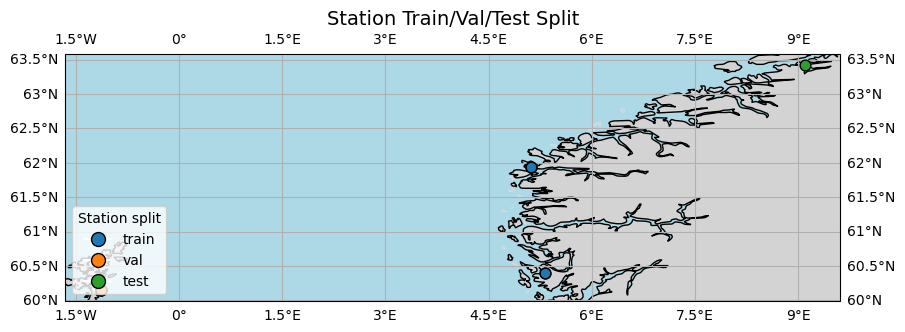

In [ ]:
# pip install cartopy matplotlib

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Station metadata from dataset
stations = ds["station"].values
lats = ds["station_latitude"].values
lons = ds["station_longitude"].values

# Assign split labels
split_labels = []
for st in stations:
    if st in train_stn:
        split_labels.append("train")
    elif st in val_stn:
        split_labels.append("val")
    elif st in test_stn:
        split_labels.append("test")
    else:
        split_labels.append("unknown")

# Map colors
colors = {"train": "tab:blue", "val": "tab:orange", "test": "tab:green", "unknown": "gray"}

# Plot
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.gridlines(draw_labels=True)

# Scatter stations
for lat, lon, label in zip(lats, lons, split_labels):
    ax.scatter(lon, lat, color=colors[label], s=60, edgecolor="k", transform=ccrs.PlateCarree(), zorder=5)

# Legend
handles = [plt.Line2D([0], [0], marker="o", color="w", label=lbl,
                      markerfacecolor=col, markersize=10, markeredgecolor="k")
           for lbl, col in colors.items() if lbl != "unknown"]
ax.legend(handles=handles, loc="lower left", title="Station split")

plt.title("Station Train/Val/Test Split", fontsize=14)
plt.show()
